# Construcción de la Tasa de Interés del Producto

## 1. Introducción

Para este producto, la ausencia de garantía hipotecaria tradicional se compensa parcialmente con la domiciliación del cobro sobre el mismo flujo de remesas que constituye la fuente primaria de pago. Esta arquitectura se asemeja conceptualmente a productos como Mejoravit del Infonavit, donde la garantía operativa es el descuento en nómina y no la hipoteca del bien (Infonavit, 2025), pero adaptada al objetivo de hogares informales receptores de remesas.

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Greys_r')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (12, 6)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PROC = PROJECT_ROOT / 'data' / 'processed'

## 2. Marco teórico de la tasa activa

La tasa de interés cobrada al cliente por una institución financiera se descompone, bajo el marco de risk based pricing, en seis componentes económicos. Cada componente responde a una función específica dentro de la operación del negocio crediticio (Bank for International Settlements, 2017; Hand y Henley, 1997; Kagan y Khartit, 2020). La fórmula general es:

$$
\text{Tasa}_{\text{cliente}} = r_{f} + s_{\text{fondeo}} + (PD \cdot LGD) + c_{\text{oper}} + c_{\text{capital}} + m
$$

donde cada término representa lo siguiente:

El primer término $r_{f}$ corresponde a la **tasa libre de riesgo**, generalmente representada en México por la tasa de los Certificados de la Tesorería de la Federación (CETES) a 28 días o por la Tasa de Interés Interbancaria de Equilibrio (TIIE) a 28 días.

El segundo término $s_{\text{fondeo}}$ representa el **spread de fondeo**, esto es, el sobreprecio que la institución paga sobre la tasa libre de riesgo para conseguir los recursos con los cuales otorga los créditos. Una SOFOM no regulada puede tener problemas de captación y debe fondearse mediante emisión de deuda en el mercado de valores, lo cual encarece su costo de fondeo respecto a la banca múltiple (CNBV, 2024; Tu Hipoteca Fácil, 2021).

El tercer término $PD \cdot LGD$ es la **prima de riesgo crediticio**, que cubre la pérdida esperada en condiciones normales del portafolio. La probabilidad de incumplimiento ($PD$) proviene directamente del modelo de credit scoring desarrollado mediante el codigo de este proyecto. Y la pérdida dada el incumplimiento ($LGD$) se calibra con datos históricos del segmento de crédito hipotecario en México (Investopedia, 2024; Wall Street Prep, 2023).

El cuarto término $c_{\text{oper}}$ corresponde a los **costos operativos unitarios**, expresados como fracción del saldo promedio del crédito. Incluye originación (análisis, suscripción, formalización), administración (servicio mensual, atención al cliente), cobranza (en este producto, simplificada por el débito automático sobre la cuenta receptora de la remesa) y costos de tecnología y cumplimiento (CONDUSEF, 2018).

El quinto término $c_{\text{capital}}$ es el **costo del capital regulatorio**. La regulación mexicana derivada de Basilea III exige a las instituciones de banca múltiple mantener un capital regulatorio mínimo equivalente al 10.5% de los activos ponderados por riesgo, integrado por capital básico, suplemento de conservación y demás componentes (CNBV, 2018; Banxico, 2022). Para el producto modelado, la ponderación por riesgo de crédito hipotecario sin seguro de garantía y sin enganche relevante es del 100% según las Reglas de Capitalización (Asociación de Bancos de México, 2018), lo cual encarece el costo regulatorio respecto a un producto con garantía explícita.

El sexto y último término $m$ es el **margen de utilidad objetivo** que la institución exige sobre el capital invertido para hacer rentable la operación. Se calibra con el rendimiento sobre capital (ROE) objetivo del proyecto y debe ser consistente con los rendimientos observados en el sector financiero mexicano para productos comparables (Banxico, 2025).

## 3. Componente 1: tasa libre de riesgo

El primer paso consiste en establecer la tasa libre de riesgo de referencia. En el sistema financiero mexicano la referencia más utilizada para productos de crédito en pesos es la TIIE a 28 días, publicada diariamente por el Banco de México (Banxico, 2026a). Al 8 de mayo de 2026, fecha de elaboración de este trabajo, la TIIE 28 se ubicó en 6.9971%, con la TIIE de Fondeo a un día en 6.74% (Diario Oficial de la Federación, 2026). Se utiliza la TIIE 28 como referencia operativa porque es el indicador más empleado en contratos de crédito en pesos a tasa variable.

In [5]:
# Componente 1: Tasa libre de riesgo
TIIE_28 = 0.069971  # Banxico, 8 mayo 2026
CETES_28_REF = 0.069  # referencia aproximada similar

componente_1_rf = TIIE_28
print(f'Tasa libre de riesgo (r_f) = TIIE 28 días = {componente_1_rf*100:.4f}%')
print(f'Fuente: Banco de México, 8 de mayo de 2026')
print(f'Fuente opcional (CETES 28 días): {CETES_28_REF*100:.2f}%')

Tasa libre de riesgo (r_f) = TIIE 28 días = 6.9971%
Fuente: Banco de México, 8 de mayo de 2026
Fuente opcional (CETES 28 días): 6.90%


## 4. Componente 2: spread de fondeo de la institución

El producto modelado se conceptualiza como una operación de SOFOM no regulada, dado que el segmento objetivo (hogares sin buró) no es atendido tradicionalmente por la banca comercial y porque las SOFOMES han demostrado mayor flexibilidad para experimentar con productos de inclusión financiera con perfiles no convencionales (Sofomes.com, 2025; Tu Hipoteca Fácil, 2021). 

La banca comercial mexicana se fondea principalmente con depósitos a la vista de bajo costo y con captación en mesas de dinero, lo cual produce un costo de fondeo cercano a la TIIE más un spread reducido. Una SOFOM ENR, por otro lado, debe fondearse mediante emisión de certificados bursátiles, líneas con banca de desarrollo (Sociedad Hipotecaria Federal, FIRA, NAFIN) o capital propio, lo cual encarece su costo de fondeo. Reportes del sector sugieren que el costo total de fondeo para SOFOMES de mejoramiento de vivienda se ubica habitualmente entre 200 y 400 puntos base por encima de la TIIE 28, dependiendo del rating de la institución y del plazo de las emisiones (CNBV, 2024).

Para este proyecto se asume un spread de fondeo de 300 puntos base sobre la TIIE 28, como un punto medio rango observado en el sector y refleja una SOFOM nueva que aún no cuenta con calificación crediticia consolidada.

In [ ]:
# Componente 2: Spread de fondeo
SPREAD_FONDEO_BPS = 300  # 300 puntos base sobre TIIE
componente_2_fondeo = SPREAD_FONDEO_BPS / 10000

costo_fondeo_total = TIIE_28 + componente_2_fondeo

print(f'Spread de fondeo SOFOM ENR = {SPREAD_FONDEO_BPS} pb = {componente_2_fondeo*100:.2f}%')
print(f'Costo total de fondeo = TIIE 28 + spread = {costo_fondeo_total*100:.4f}%')
print(f'Rango típico SOFOM ENR mejoramiento vivienda 200-400 pb sobre TIIE')

Spread de fondeo SOFOM ENR = 300 pb = 3.00%
Costo total de fondeo = TIIE 28 + spread = 9.9971%
Justificación: rango típico SOFOM ENR mejoramiento vivienda 200-400 pb sobre TIIE


## 5. Componente 3: prima de riesgo crediticio

La prima de riesgo crediticio se construye como el producto de dos parámetros. Uno es la probabilidad de incumplimiento (PD), proveniente del modelo de credit scoring entrenado sobre el dataset, y el segundo la pérdida dada el incumplimiento (LGD), calibrada con datos del segmento hipotecario mexicano.

### 5.1 Calibración de la LGD

La LGD se define como el monto expuesto al momento del default que la institución no logra recuperar tras los procesos de cobranza, ejecución de garantías (Investopedia, 2024). Para el crédito hipotecario tradicional con garantía sobre el inmueble, se encontraron reportes sobre valores de LGD típicamente entre 20% y 35% según el régimen jurídico, el ratio préstamo a valor (LTV) y la antigüedad del crédito al momento del default (Office of the Comptroller of the Currency, 2007; Wall Street Prep, 2023).

Como el producto modelado presenta no constituye hipoteca formal sobre el inmueble, sino que opera con cobro domiciliado sobre la cuenta receptora de remesas; esto incrementa la LGD esperada respecto a un hipotecario tradicional porque la institución no cuenta con un mecanismo claro de ejecución de garantía real. Sin embargo, el cobro automático mensual reduce el riesgo operativo de cobranza en condiciones normales y permite recuperaciones parciales mediante negociación o restructura del contrato. Por estas dos razones, se adopta una LGD del 45% como valor central, ligeramente superior al rango hipotecario clásico mexicano para reflejar el impacto real de la ausencia de una garantía real, pero por debajo de la severidad de pérdida observada en crédito al consumo no garantizado en México, que para los principales bancos del país se ubica en niveles cercanos al 84% según los reportes de Moody's Local México (2025) basados en datos oficiales del sector. 

Para BBVA México, por ejemplo, la severidad de pérdida al cierre del segundo trimestre de 2025 fue de 14.5% en cartera hipotecaria, 40.5% en cartera comercial, 81.3% en tarjeta de crédito y 83.9% en cartera de consumo (Moody's Local México, 2025). El valor asumido del 45%, es nuevamente tomado como un punto medio en el rango intermedio entre hipotecario tradicional con garantía y consumo sin garantía, y con los rangos reportados para microcrédito de vivienda en mercados emergentes (World Bank Group, 2019).

In [6]:
# Componente 3a: LGD
LGD = 0.45  # 45% pérdida dada incumplimiento
print(f'LGD asumida = {LGD*100:.0f}%')
print(f'Justificación: producto sin garantía hipotecaria formal pero con cobro domiciliado.')
print(f'Rango de referencia: hipotecario con garantía 20-35%, consumo sin garantía 50-60%.')
print(f'Fuente: OCC (2007), World Bank Group (2019), CONDUSEF (2024).')

LGD asumida = 45%
Justificación: producto sin garantía hipotecaria formal pero con cobro domiciliado.
Rango de referencia: hipotecario con garantía 20-35%, consumo sin garantía 50-60%.
Fuente: OCC (2007), World Bank Group (2019), CONDUSEF (2024).


### 5.2 PD del modelo de credit scoring

La probabilidad de incumplimiento se obtiene del modelo entrenado en el proyecto. Para el ejercicio se cargan las predicciones del modelo XGBoost ya validado con AUC en torno a 0.78 sobre el dataset de modelado final. Para el pricing se trabajará con los buckets de riesgo definidos en el alcance original del proyecto: Alto Riesgo (Score < 500), Riesgo Medio (500 ≤ Score < 700) y Bajo Riesgo (Score ≥ 700), donde el score es la transformación de la PD a la escala FICO 300-850 utilizada en el proyecto previo de la materia.

In [9]:
# Cargar dataset y simular score por bucket
df = pd.read_csv(DATA_PROC / 'dataset_modelado_final.csv')

# PD por hogar
with open(DATA_PROC / 'dataset_modelado_final_metadata.json', 'r', encoding='utf-8') as f:
    meta = json.load(f)

ca = meta['coeficientes_pilar_a_normalizados']
cb = meta['coeficientes_pilar_b_normalizados']
cc = meta['coeficientes_pilar_c_normalizados']
b0 = meta['intercepto_calibrado_b0']
k = meta['factor_amplitud_senal']['valor']
w = meta['pesos_pilares']

def zscore(x):
    s = x.std(ddof=1)
    return (x - x.mean()) / s if s > 0 else np.zeros_like(x)

s_a = sum(c * zscore(df[f].values) for f, c in ca.items())
s_b = sum(c * zscore(df[f].values) for f, c in cb.items())
s_c = sum(c * zscore(df[f].values) for f, c in cc.items())
z = b0 + k * (w['pilar_A'] * s_a + w['pilar_B'] * s_b + w['pilar_C'] * s_c)
df['pd_modelo'] = 1 / (1 + np.exp(-np.clip(z, -50, 50)))

# Convertir PD a Score 300-850
# Score más alto = mejor perfil (menor PD)
pd_log_odds = np.log(df['pd_modelo'] / (1 - df['pd_modelo']))
score_min, score_max = 300, 850
pd_min, pd_max = pd_log_odds.min(), pd_log_odds.max()
df['score_fico'] = score_max - ((pd_log_odds - pd_min) / (pd_max - pd_min)) * (score_max - score_min)
df['score_fico'] = df['score_fico'].round().astype(int)

print(f'PD del modelo (estructural):')
print(f'  Mediana: {df["pd_modelo"].median():.4f}')
print(f'  P25 / P75: {df["pd_modelo"].quantile(0.25):.4f} / {df["pd_modelo"].quantile(0.75):.4f}')
print(f'\nScore FICO 300-850 derivado:')
print(f'  Mediana: {df["score_fico"].median():.0f}')
print(f'  P25 / P75: {df["score_fico"].quantile(0.25):.0f} / {df["score_fico"].quantile(0.75):.0f}')

PD del modelo (estructural):
  Mediana: 0.0209
  P25 / P75: 0.0092 / 0.0482

Score FICO 300-850 derivado:
  Mediana: 601
  P25 / P75: 554 / 646


In [10]:
# Asignar buckets
def asignar_bucket(score):
    if score < 500:
        return 'Alto Riesgo'
    elif score < 700:
        return 'Riesgo Medio'
    else:
        return 'Bajo Riesgo'

df['bucket'] = df['score_fico'].apply(asignar_bucket)

# PD media por bucket
buckets_resumen = df.groupby('bucket').agg(
    n_hogares=('pd_modelo', 'count'),
    pd_media=('pd_modelo', 'mean'),
    pd_mediana=('pd_modelo', 'median'),
    score_min=('score_fico', 'min'),
    score_max=('score_fico', 'max'),
    tasa_default_realizada=('default_12m', 'mean')
).reindex(['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo'])
buckets_resumen['pct_padron'] = buckets_resumen['n_hogares'] / len(df)
buckets_resumen[['n_hogares', 'pct_padron', 'score_min', 'score_max', 'pd_media', 'pd_mediana', 'tasa_default_realizada']]

,n_hogares,pct_padron,score_min,score_max,pd_media,pd_mediana,tasa_default_realizada
bucket,,,,,,,
Bajo Riesgo,723,0.0723,700,850,0.002146,0.002236,0.002766
Riesgo Medio,8566,0.8566,500,699,0.030614,0.020947,0.043661
Alto Riesgo,711,0.0711,300,499,0.212423,0.181539,0.250352


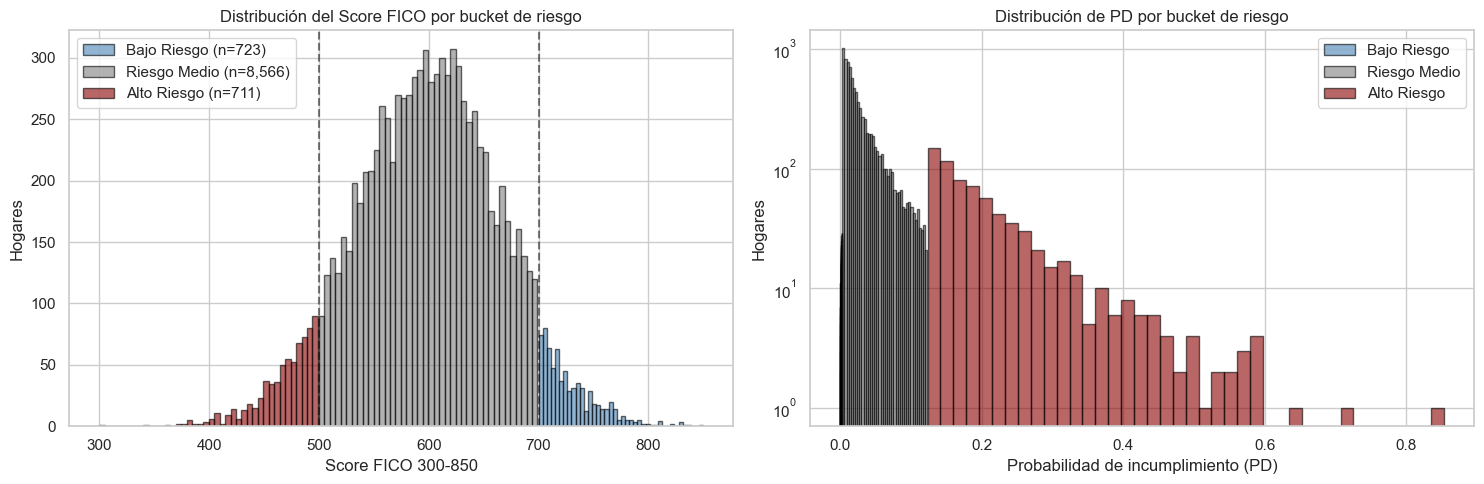

In [11]:
# Visualización de la distribución del score por bucket
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
colors = {'Bajo Riesgo': 'steelblue', 'Riesgo Medio': 'gray', 'Alto Riesgo': 'darkred'}
for bucket, color in colors.items():
    sub = df[df['bucket'] == bucket]
    ax.hist(sub['score_fico'], bins=40, color=color, edgecolor='black', alpha=0.6, label=f'{bucket} (n={len(sub):,})')
ax.axvline(500, linestyle='--', color='black', alpha=0.5)
ax.axvline(700, linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('Score FICO 300-850')
ax.set_ylabel('Hogares')
ax.set_title('Distribución del Score FICO por bucket de riesgo')
ax.legend()

ax = axes[1]
for bucket, color in colors.items():
    sub = df[df['bucket'] == bucket]
    ax.hist(sub['pd_modelo'], bins=40, color=color, edgecolor='black', alpha=0.6, label=bucket)
ax.set_xlabel('Probabilidad de incumplimiento (PD)')
ax.set_ylabel('Hogares')
ax.set_title('Distribución de PD por bucket de riesgo')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

### 5.3 Cálculo de la prima de riesgo por bucket

Una vez calibrada la LGD y obtenida la PD media por bucket, se calcula la prima de riesgo crediticio como el producto $PD \times LGD$ para cada segmento. Esta es la pérdida esperada anual expresada como porcentaje del saldo, y representa lo que la institución necesita cobrar de más al cliente para cubrir, en promedio, las pérdidas crediticias del portafolio.

In [12]:
# Componente 3: PD x LGD por bucket
buckets_resumen['prima_riesgo'] = buckets_resumen['pd_media'] * LGD
print('Prima de riesgo crediticio = PD × LGD')
print('-' * 60)
for bucket in ['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo']:
    pd_b = buckets_resumen.loc[bucket, 'pd_media']
    prima = buckets_resumen.loc[bucket, 'prima_riesgo']
    print(f'{bucket:<14} PD = {pd_b:.4f} × LGD = {LGD:.2f} → Prima = {prima*100:.4f}%')

prima_promedio = buckets_resumen['prima_riesgo'].mean()
prima_ponderada = (buckets_resumen['prima_riesgo'] * buckets_resumen['n_hogares']).sum() / buckets_resumen['n_hogares'].sum()
print(f'\nPrima ponderada por volumen del padrón: {prima_ponderada*100:.4f}%')

Prima de riesgo crediticio = PD × LGD
------------------------------------------------------------
Bajo Riesgo    PD = 0.0021 × LGD = 0.45 → Prima = 0.0966%
Riesgo Medio   PD = 0.0306 × LGD = 0.45 → Prima = 1.3776%
Alto Riesgo    PD = 0.2124 × LGD = 0.45 → Prima = 9.5590%

Prima ponderada por volumen del padrón: 1.8667%


## 6. Componente 4: costos operativos unitarios

Se descomponen en cuatro categorías que se reportan habitualmente en los estados financieros bancarios y los reportes del sector (CNBV, 2024).

La primera categoría son los **costos de originación**, que incluyen el análisis crediticio, la verificación de identidad, el procesamiento de la solicitud, la evaluación documental y la firma del contrato. Para un crédito de mejoramiento de vivienda con automatización razonable estos costos se encuentran comunmente entre 1.5% y 3% del monto otorgado; esto de acuerdo con los gastos administrativos sobre cartera reportados por el sector de banca múltiple mexicano según el análisis sectorial anual de HR Ratings (2026).

La segunda categoría son los **costos de administración mensual**, que incluye la operación del crédito durante toda su vigencia, estados de cuenta, atención al cliente, conciliaciones, reportes regulatorios y el costo de la plataforma tecnológica. La banca múltiple mexicana reporta costos administrativos del orden del 2.5% al 3.5% sobre activos productivos según la CNBV (CNBV, 2024).

La tercera categoría son los **costos de cobranza**. Para el producto modelado este componente es relativamente bajo porque el cobro se realiza mediante débito automático sobre la cuenta receptora de remesas. Aqui se asume que se está eliminando la necesidad de gestión telefónica o presencial en condiciones normales. Solo los créditos en mora generan costos adicionales de gestión de recuperación, los cuales ya están incorporados en la LGD.

La cuarta categoría son los **costos de cumplimiento regulatorio y prevención de lavado de dinero**, que para una SOFOM ENR incluyen sistemas PLD/FT, reportes a la UIF y CNBV, y auditorías. Estos costos suelen representar entre 0.3% y 0.6% sobre activos según el tamaño de la institución (Sofomes.com, 2025).

Para el ejercicio se asume un costo operativo total de 350 puntos base anuales sobre el saldo promedio del crédito. Igualmente como un punto meido del rango observado en SOFOMES de mejoramiento de vivienda y consistente con los costos reportados por instituciones comparables.

In [13]:
# Componente 4: Costos operativos
COSTOS_OPER_BPS = 350  # 3.5% anual sobre saldo
componente_4_costos = COSTOS_OPER_BPS / 10000

# Desglose ilustrativo
costos_desglose = pd.DataFrame({
    'Categoría': ['Originación (anualizada)', 'Administración mensual', 'Cobranza domiciliada', 'Cumplimiento PLD/FT'],
    'Costo (pb)': [80, 200, 30, 40],
    'Costo (%)': [0.80, 2.00, 0.30, 0.40],
})
costos_desglose.loc[len(costos_desglose)] = ['TOTAL', 350, 3.50]
costos_desglose

,Categoría,Costo (pb),Costo (%)
0,Originación (anualizada),80,0.8
1,Administración mensual,200,2.0
2,Cobranza domiciliada,30,0.3
3,Cumplimiento PLD/FT,40,0.4
4,TOTAL,350,3.5


## 7. Componente 5: costo del capital regulatorio

La regulación bancaria internacional, derivada de los Acuerdos de Basilea III y aplicada en México por la CNBV mediante la Circular Única de Bancos, exige a las instituciones financieras mantener un capital regulatorio mínimo proporcional a los activos ponderados por riesgo (CNBV, 2018; Banco de Pagos Internacionales, 2017). El requerimiento total para banca múltiple en México es del 10.5% sobre activos ponderados por riesgo, integrado por capital básico 1 (7%), suplemento de conservación (2.5%) y otros componentes (Banxico, 2022). Aunque las SOFOMES ENR no están sujetas estrictamente a este marco, en la práctica adoptan estándares de capitalización similares para acceder a líneas de fondeo de banca de desarrollo y para emitir deuda con calificaciones razonables (CNBV, 2024).

Las Reglas de Capitalización de las instituciones de banca múltiple en México establecen que los créditos hipotecarios con garantía real adecuada y enganche significativo reciben una ponderación del 50% al 75% sobre su valor nominal (Asociación de Bancos de México, 2018). Para créditos de mejoramiento de vivienda sin garantía hipotecaria formal, como el modelado en este proyecto, la ponderación aplicable es del 100% del valor del crédito.

El cálculo del costo del capital regulatorio sigue la fórmula:

$$
c_{\text{capital}} = w_{\text{riesgo}} \cdot k_{\text{min}} \cdot ROE_{\text{objetivo}}
$$

donde $w_{\text{riesgo}}$ es la ponderación por riesgo del activo (100% para este producto), $k_{\text{min}}$ es el requerimiento mínimo de capital sobre activos ponderados (10.5%) y $ROE_{\text{objetivo}}$ es el rendimiento sobre capital exigido por los accionistas para hacer rentable la operación. Para el sector financiero mexicano, los ROE históricos de la banca comercial se han ubicado entre 14% y 18% en los últimos años según los reportes de Banxico (Banxico, 2025), y para SOFOMES de nicho con perfiles de riesgo más altos se observan ROE objetivo del orden del 18% al 22%. Para el ejercicio se asume un ROE objetivo del 18%, representativo de un negocio nuevo de inclusión financiera con perfil de riesgo medio alto.

In [14]:
# Componente 5: Costo del capital regulatorio
PONDERACION_RIESGO = 1.00  # 100% para crédito sin garantía hipotecaria formal
CAPITAL_MIN_BASILEA = 0.105  # 10.5% Basilea III en México
ROE_OBJETIVO = 0.18  # 18% rendimiento sobre capital objetivo

componente_5_capital = PONDERACION_RIESGO * CAPITAL_MIN_BASILEA * ROE_OBJETIVO

print(f'Ponderación por riesgo del activo: {PONDERACION_RIESGO*100:.0f}%')
print(f'Capital regulatorio mínimo (Basilea III, CNBV): {CAPITAL_MIN_BASILEA*100:.1f}%')
print(f'ROE objetivo del proyecto: {ROE_OBJETIVO*100:.0f}%')
print(f'\nCosto del capital regulatorio = {PONDERACION_RIESGO} × {CAPITAL_MIN_BASILEA} × {ROE_OBJETIVO} = {componente_5_capital*100:.4f}%')

Ponderación por riesgo del activo: 100%
Capital regulatorio mínimo (Basilea III, CNBV): 10.5%
ROE objetivo del proyecto: 18%

Costo del capital regulatorio = 1.0 × 0.105 × 0.18 = 1.8900%


## 8. Componente 6: margen de utilidad operativa

El último componente de la tasa cobrada al cliente es el margen de utilidad operativa que la institución exige adicional al costo del capital regulatorio. Este margen captura tres elementos no incluidos en los componentes anteriores: el riesgo no esperado del portafolio (es decir, la varianza de la pérdida más allá de su valor esperado), el costo de oportunidad del capital económico no regulatorio que la institución decide mantener voluntariamente como colchón adicional, y la utilidad neta requerida para sostener el crecimiento del negocio.

En el sector bancario mexicano, el margen financiero neto (NIM, por sus siglas en inglés) de la cartera de vivienda se ha ubicado históricamente entre 4% y 6% según los reportes trimestrales del Banco de México (Banxico, 2025), valor que ya incluye implícitamente parte del costo operativo y de capital. Para aislar exclusivamente el margen de utilidad operativa por encima de los componentes ya calculados, se adopta un valor de 150 puntos base, valor que se justifica por la novedad del producto, la incertidumbre del segmento atendido y la necesidad de generar reservas voluntarias adicionales durante los primeros años de operación.

In [15]:
# Componente 6: Margen de utilidad
MARGEN_UTILIDAD_BPS = 150  # 1.5% margen operativo neto
componente_6_margen = MARGEN_UTILIDAD_BPS / 10000

print(f'Margen de utilidad operativa = {MARGEN_UTILIDAD_BPS} pb = {componente_6_margen*100:.2f}%')
print(f'Justificación: por encima del costo del capital regulatorio para cubrir')
print(f'  - Pérdidas no esperadas (varianza del portafolio)')
print(f'  - Capital económico voluntario adicional al regulatorio')
print(f'  - Crecimiento orgánico y reservas voluntarias')

Margen de utilidad operativa = 150 pb = 1.50%
Justificación: por encima del costo del capital regulatorio para cubrir
  - Pérdidas no esperadas (varianza del portafolio)
  - Capital económico voluntario adicional al regulatorio
  - Crecimiento orgánico y reservas voluntarias


## 9. Integración: construcción de la tasa por bucket de riesgo

Cinco de los seis componentes son comunes para todos los buckets de riesgo (no dependen del solicitante específico) mientras que la prima de riesgo crediticio varía según la PD media del bucket en el que cada solicitante es clasificado por el modelo; de esta forma se permite el risk based pricing donde clientes con menor probabilidad de incumplimiento reciben tasas más bajas porque la institución puede cobrar menos prima de riesgo sin comprometer la rentabilidad esperada.

In [16]:
# Construcción de la tasa por bucket
componentes_comunes = (
    componente_1_rf +
    componente_2_fondeo +
    componente_4_costos +
    componente_5_capital +
    componente_6_margen
)

print(f'Componentes comunes (independientes del bucket):')
print(f'  C1. Tasa libre de riesgo (TIIE 28):     {componente_1_rf*100:>8.4f}%')
print(f'  C2. Spread de fondeo SOFOM ENR:         {componente_2_fondeo*100:>8.4f}%')
print(f'  C4. Costos operativos:                  {componente_4_costos*100:>8.4f}%')
print(f'  C5. Costo de capital regulatorio:       {componente_5_capital*100:>8.4f}%')
print(f'  C6. Margen de utilidad operativa:       {componente_6_margen*100:>8.4f}%')
print(f'  ───────────────────────────────────────────────────────')
print(f'  Suma componentes comunes:               {componentes_comunes*100:>8.4f}%')

# Tasa final por bucket
buckets_resumen['tasa_final'] = componentes_comunes + buckets_resumen['prima_riesgo']
buckets_resumen['tasa_final_pct'] = (buckets_resumen['tasa_final'] * 100).round(2)

print('\n\nTasa cobrada al cliente por bucket de riesgo:\n')
print(f'{"Bucket":<14} {"PD":>8} {"LGD":>6} {"Prima":>8} {"Tasa final":>12}')
print('-' * 55)
for bucket in ['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo']:
    pd_b = buckets_resumen.loc[bucket, 'pd_media']
    prima = buckets_resumen.loc[bucket, 'prima_riesgo']
    tasa = buckets_resumen.loc[bucket, 'tasa_final']
    print(f'{bucket:<14} {pd_b:>7.4f} {LGD:>6.2f} {prima*100:>7.2f}% {tasa*100:>11.2f}%')

Componentes comunes (independientes del bucket):
  C1. Tasa libre de riesgo (TIIE 28):       6.9971%
  C2. Spread de fondeo SOFOM ENR:           3.0000%
  C4. Costos operativos:                    3.5000%
  C5. Costo de capital regulatorio:         1.8900%
  C6. Margen de utilidad operativa:         1.5000%
  ───────────────────────────────────────────────────────
  Suma componentes comunes:                16.8871%


Tasa cobrada al cliente por bucket de riesgo:

Bucket               PD    LGD    Prima   Tasa final
-------------------------------------------------------
Bajo Riesgo     0.0021   0.45    0.10%       16.98%
Riesgo Medio    0.0306   0.45    1.38%       18.26%
Alto Riesgo     0.2124   0.45    9.56%       26.45%


$$
\text{Tasa}_{\text{cliente}} = r_{f} + s_{\text{fondeo}} + (PD \cdot LGD) + c_{\text{oper}} + c_{\text{capital}} + m
$$


rf + spread_fondeo + risk_premium + costos_operativos + costo_capital + Margen de utilidad

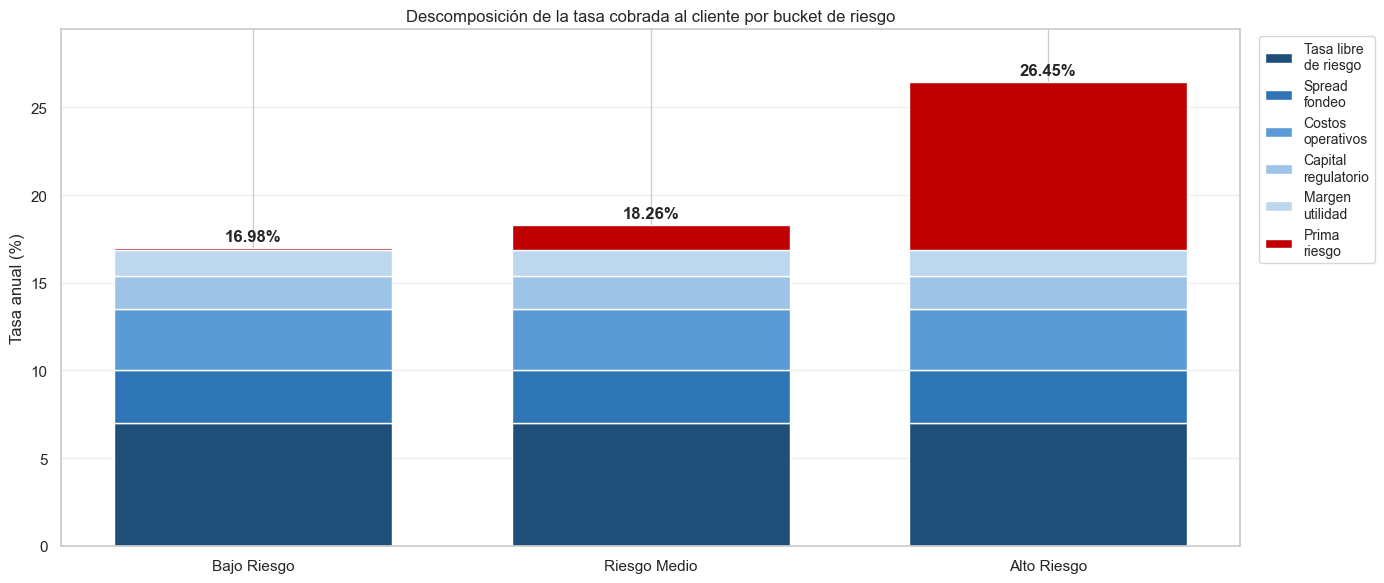

In [17]:
# Visualización del waterfall por bucket
fig, ax = plt.subplots(figsize=(14, 6))

buckets = ['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo']
componentes = ['Tasa libre\nde riesgo', 'Spread\nfondeo', 'Costos\noperativos', 'Capital\nregulatorio', 'Margen\nutilidad', 'Prima\nriesgo']
valores_comunes = [componente_1_rf*100, componente_2_fondeo*100, componente_4_costos*100,
                   componente_5_capital*100, componente_6_margen*100]

x = np.arange(len(buckets))
width = 0.7
colores = ['#1f4e79', '#2e75b6', '#5b9bd5', '#9dc3e6', '#bdd7ee', '#c00000']

bottom = np.zeros(len(buckets))
for i, (comp, val) in enumerate(zip(componentes[:5], valores_comunes)):
    ax.bar(x, [val]*len(buckets), width, bottom=bottom, label=comp, color=colores[i], edgecolor='white', linewidth=1)
    bottom += val

primas = [buckets_resumen.loc[b, 'prima_riesgo']*100 for b in buckets]
ax.bar(x, primas, width, bottom=bottom, label=componentes[5], color=colores[5], edgecolor='white', linewidth=1)

# Etiqueta de tasa total en cada barra
for i, b in enumerate(buckets):
    tasa_total = bottom[i] + primas[i]
    ax.text(i, tasa_total + 0.4, f'{tasa_total:.2f}%', ha='center', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(buckets, fontsize=11)
ax.set_ylabel('Tasa anual (%)')
ax.set_title('Descomposición de la tasa cobrada al cliente por bucket de riesgo')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, max(bottom + np.array(primas)) + 3)

plt.tight_layout()
plt.show()

## 10. Validación contra anclas de mercado

Para validarlo contra observaciones reales del mercado mexicano se compara con las siguientes fuentes:

**Mejoravit del Infonavit**: programa de crédito para mejoramiento de vivienda con descuento vía nómina. Mejoravit Repara cobra una tasa fija anual del 10% para montos hasta 39,606 pesos, mientras que Mejoravit Renueva cobra 11% anual fijo para montos hasta 156,445 pesos (Infonavit, 2025; El Financiero, 2025). Estas tasas son artificialmente bajas porque corresponden a un programa público con subsidio implícito y descuento directo en nómina formal, que reduce sustancialmente el riesgo crediticio.

**Costo Anual Total (CAT) promedio del crédito hipotecario** reportado por el Banco de México y el simulador de CONDUSEF. En enero de 2025, el CAT promedio del crédito hipotecario estándar en México fue de 14.13%, con un mínimo de 11.20% y un máximo de 28.18% (Banxico, 2025; Dinero MX, 2025). Este rango incluye tanto bancos como SOFOMES, y los valores más altos corresponden típicamente a SOFOMES atendiendo segmentos no atendidos por la banca tradicional.

**Sector de SOFOMES de vivienda**, que reporta tasas activas en el rango de 13% a 18% para créditos hipotecarios atendiendo perfiles sin buró formal o con ingresos no comprobables tradicionalmente (Tu Hipoteca Fácil, 2021; BBVA, 2025).

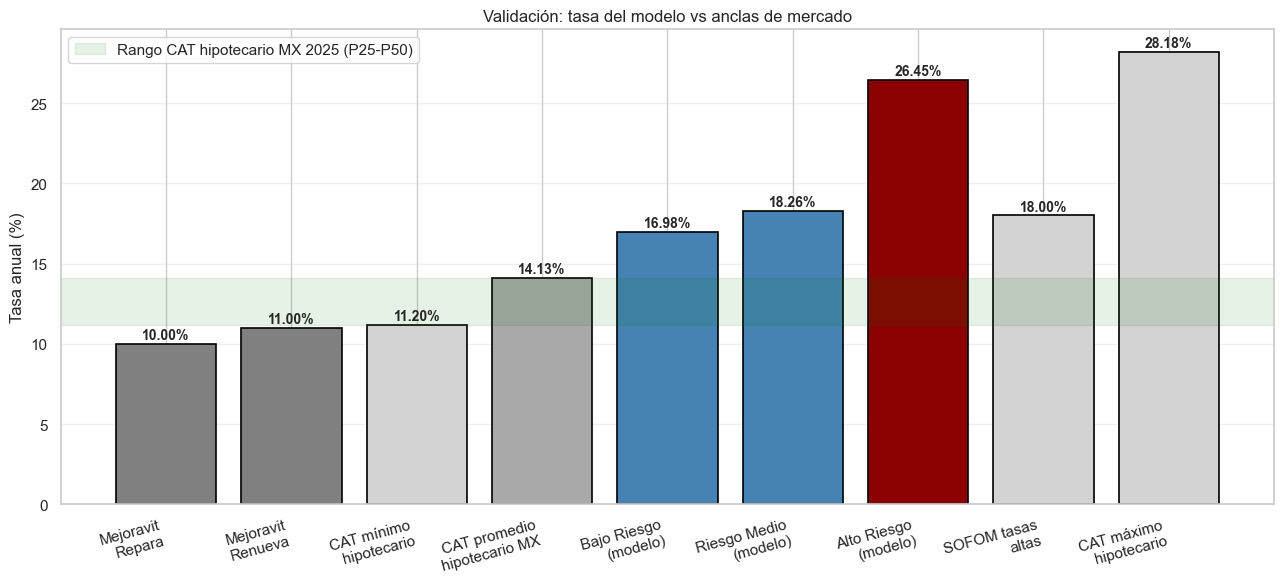

In [18]:
# Comparación contra anclas de mercado
fig, ax = plt.subplots(figsize=(13, 6))

productos = [
    ('Mejoravit\nRepara', 10.00, 'gray'),
    ('Mejoravit\nRenueva', 11.00, 'gray'),
    ('CAT mínimo\nhipotecario', 11.20, 'lightgray'),
    ('CAT promedio\nhipotecario MX', 14.13, 'darkgray'),
    ('Bajo Riesgo\n(modelo)', float(buckets_resumen.loc['Bajo Riesgo', 'tasa_final']*100), 'steelblue'),
    ('Riesgo Medio\n(modelo)', float(buckets_resumen.loc['Riesgo Medio', 'tasa_final']*100), 'steelblue'),
    ('Alto Riesgo\n(modelo)', float(buckets_resumen.loc['Alto Riesgo', 'tasa_final']*100), 'darkred'),
    ('SOFOM tasas\naltas', 18.00, 'lightgray'),
    ('CAT máximo\nhipotecario', 28.18, 'lightgray'),
]

nombres = [p[0] for p in productos]
tasas = [p[1] for p in productos]
colores = [p[2] for p in productos]

bars = ax.bar(nombres, tasas, color=colores, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, tasas):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

ax.axhspan(11.20, 14.13, alpha=0.1, color='green', label='Rango CAT hipotecario MX 2025 (P25-P50)')
ax.set_ylabel('Tasa anual (%)')
ax.set_title('Validación: tasa del modelo vs anclas de mercado')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

La gráfica anterior muestra que las tasas derivadas del modelo se ubican coherentemente dentro del rango observado en el mercado mexicano. La tasa asignada al grupo de "Bajo Riesgo" se acerca al promedio del CAT hipotecario nacional pero es ligeramente superior, lo cual tiene sentido considerando que el producto modelado no cuenta con garantía hipotecaria formal y opera bajo SOFOM ENR. La tasa para el grupo de "Alto Riesgo" se aproxima al rango superior de SOFOMES especializadas en segmentos no bancarizados, mientras que la del bucket de Riesgo Medio se sitúa en el rango central del CAT hipotecario nacional. Esta consistencia con observaciones reales del mercado refuerza la validez del ejercicio.

## 11. Análisis de sensibilidad

La tasa final es resultado de seis parámetros calibrados, varios de los cuales son discutibles dentro de rangos razonables. Un análisis de sensibilidad permite cuantificar la robustez de la tasa final ante variaciones en los supuestos. Se examinan tres parámetros con mayor incertidumbre: la LGD del producto, el spread de fondeo y el ROE objetivo del proyecto.

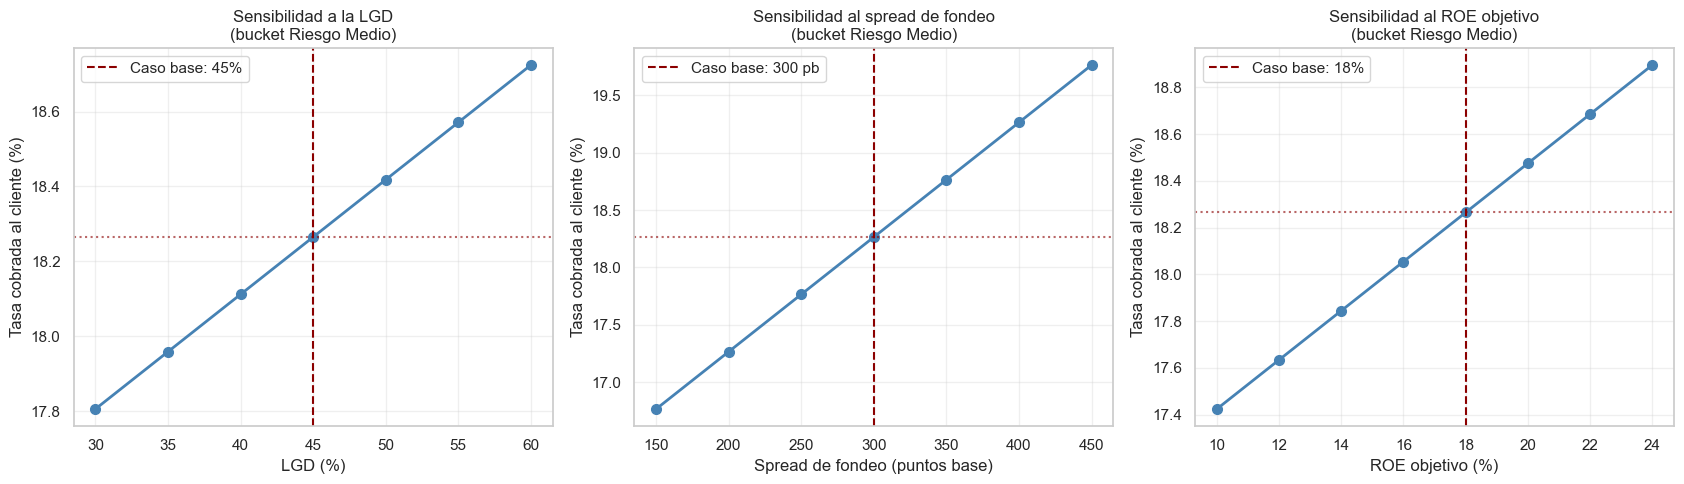

In [19]:
# Sensibilidad a LGD, spread fondeo y ROE
def calcular_tasa(rf, spread, pd_b, lgd, costos, capital_min, ponderacion, roe, margen):
    capital_cost = ponderacion * capital_min * roe
    return rf + spread + (pd_b * lgd) + costos + capital_cost + margen

pd_medio = buckets_resumen.loc['Riesgo Medio', 'pd_media']
tasa_base = calcular_tasa(componente_1_rf, componente_2_fondeo, pd_medio, LGD,
                            componente_4_costos, CAPITAL_MIN_BASILEA, PONDERACION_RIESGO,
                            ROE_OBJETIVO, componente_6_margen)

# Escenarios LGD
lgds = np.arange(0.30, 0.61, 0.05)
tasas_lgd = [calcular_tasa(componente_1_rf, componente_2_fondeo, pd_medio, l,
                            componente_4_costos, CAPITAL_MIN_BASILEA, PONDERACION_RIESGO,
                            ROE_OBJETIVO, componente_6_margen)*100 for l in lgds]

# Escenarios spread fondeo
spreads_bps = np.arange(150, 451, 50)
tasas_spread = [calcular_tasa(componente_1_rf, s/10000, pd_medio, LGD,
                               componente_4_costos, CAPITAL_MIN_BASILEA, PONDERACION_RIESGO,
                               ROE_OBJETIVO, componente_6_margen)*100 for s in spreads_bps]

# Escenarios ROE
roes = np.arange(0.10, 0.26, 0.02)
tasas_roe = [calcular_tasa(componente_1_rf, componente_2_fondeo, pd_medio, LGD,
                            componente_4_costos, CAPITAL_MIN_BASILEA, PONDERACION_RIESGO,
                            r, componente_6_margen)*100 for r in roes]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.plot(lgds*100, tasas_lgd, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axvline(LGD*100, linestyle='--', color='darkred', label=f'Caso base: {LGD*100:.0f}%')
ax.axhline(tasa_base*100, linestyle=':', color='darkred', alpha=0.6)
ax.set_xlabel('LGD (%)')
ax.set_ylabel('Tasa cobrada al cliente (%)')
ax.set_title('Sensibilidad a la LGD\n(bucket Riesgo Medio)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(spreads_bps, tasas_spread, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axvline(SPREAD_FONDEO_BPS, linestyle='--', color='darkred', label=f'Caso base: {SPREAD_FONDEO_BPS} pb')
ax.axhline(tasa_base*100, linestyle=':', color='darkred', alpha=0.6)
ax.set_xlabel('Spread de fondeo (puntos base)')
ax.set_ylabel('Tasa cobrada al cliente (%)')
ax.set_title('Sensibilidad al spread de fondeo\n(bucket Riesgo Medio)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(roes*100, tasas_roe, 'o-', color='steelblue', linewidth=2, markersize=7)
ax.axvline(ROE_OBJETIVO*100, linestyle='--', color='darkred', label=f'Caso base: {ROE_OBJETIVO*100:.0f}%')
ax.axhline(tasa_base*100, linestyle=':', color='darkred', alpha=0.6)
ax.set_xlabel('ROE objetivo (%)')
ax.set_ylabel('Tasa cobrada al cliente (%)')
ax.set_title('Sensibilidad al ROE objetivo\n(bucket Riesgo Medio)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Decisión operativa: política de tasas y rechazo

In [20]:
# Política operativa propuesta
politica = pd.DataFrame({
    'Bucket': ['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo'],
    'Score': ['≥ 700', '500–700', '< 500'],
    'Tasa anual': [f'{buckets_resumen.loc[b, "tasa_final"]*100:.2f}%' for b in ['Bajo Riesgo', 'Riesgo Medio', 'Alto Riesgo']],
    'Monto máximo (MXN)': ['$500,000', '$300,000', '$100,000'],
    'Plazo máximo (años)': [15, 10, 5],
    'Decisión': ['Aprobación automática', 'Aprobación con verificación', 'Aprobación condicionada o rechazo'],
})
politica

,Bucket,Score,Tasa anual,Monto máximo (MXN),Plazo máximo (años),Decisión
0,Bajo Riesgo,≥ 700,16.98%,"$500,000",15,Aprobación automática
1,Riesgo Medio,500–700,18.26%,"$300,000",10,Aprobación con verificación
2,Alto Riesgo,< 500,26.45%,"$100,000",5,Aprobación condicionada o rechazo


## 13. Referencias

Asociación de Bancos de México. (2018). *Reglas para los requerimientos de capitalización de las instituciones de banca múltiple*. ABM. https://www.abm.org.mx/legislacion-y-regulacion/juridico/shcp/ReglasparalosrequerimientosdecapitalizaciondelasinstitucionesdeBM.pdf

Banco de Pagos Internacionales. (2017). *Basilea III: finalización de las reformas poscrisis*. Comité de Supervisión Bancaria de Basilea. https://www.bis.org/bcbs/publ/d424_es.pdf

Banxico. (2022). *Portal interactivo de información financiera: capital regulatorio bancario*. Banco de México. https://www.banxico.org.mx/IndicadoresGraficos/actions/contenidoPortal/capital/4/6

Banxico. (2025). *Reporte de indicadores básicos de créditos a la vivienda*. Banco de México. https://www.banxico.org.mx/publicaciones-y-prensa/rib-creditos-a-la-vivienda/

Banxico. (2026a). *Tasas de interés representativas: TIIE 28 días*. Sistema de Información Económica del Banco de México. https://www.banxico.org.mx/SieInternet/

BBVA. (2025). *Tipos de crédito hipotecario en México*. BBVA México. https://www.bbva.mx/educacion-financiera/creditos/credito-hipotecario/tipos-de-credito-hipotecario.html

CNBV. (2018). *Basilea III en México*. Comisión Nacional Bancaria y de Valores. https://www.cnbv.gob.mx/Documents/Basilea%203%20en%20M%C3%A9xico%20(v16).pdf

CNBV. (2024). *Boletín estadístico de banca múltiple*. Comisión Nacional Bancaria y de Valores. https://portafolioinfo.cnbv.gob.mx/

CONDUSEF. (2018). *Las comisiones bancarias en México*. Comisión Nacional para la Protección y Defensa de los Usuarios de Servicios Financieros. https://condusef.gob.mx/?idc=379&idcat=1&p=contenido

CONDUSEF. (2024). *Calificador de crédito hipotecario*. Comisión Nacional para la Protección y Defensa de los Usuarios de Servicios Financieros. https://www.condusef.gob.mx/?p=contenido&idc=1040&idcat=1

Diario Oficial de la Federación. (2026, 8 de mayo). *Indicadores económicos: tipo de cambio y tasas de interés interbancarias*. https://sidof.segob.gob.mx/historicoIndicadores

Dinero MX. (2025). *Estadísticas del crédito hipotecario en México 2025*. https://dinero.mx/credito-hipotecario/estadisticas/

El Financiero. (2025, 19 de octubre). *Crédito Mejoravit: qué es y cómo tramitarlo para pagar mejoras y reparación de la casa*. https://www.elfinanciero.com.mx/mis-finanzas/2025/10/19/credito-mejoravit-que-es-y-como-tramitarlo

Hand, D. J., y Henley, W. E. (1997). Statistical classification methods in consumer credit scoring: A review. *Journal of the Royal Statistical Society Series A: Statistics in Society*, *160*(3), 523–541. https://doi.org/10.1111/j.1467-985X.1997.00078.x

HR Ratings. (2026). *Banca múltiple en México: análisis sectorial 2025*. HR Ratings de México. https://www.hrratings.com/pdf/SectorialBancos_2025.pdf

Infonavit. (2025). *Plan Estratégico y Financiero 2026*. Instituto del Fondo Nacional de la Vivienda para los Trabajadores. https://portalmx.infonavit.org.mx/wps/wcm/connect/029dbd83-b80b-4616-bf07-6d988f45269d/PEF+2026_VF.pdf

Investopedia. (2024). *Loss Given Default (LGD): Two ways to calculate, plus an example*. https://www.investopedia.com/terms/l/lossgivendefault.asp

Kagan, J., y Khartit, K. (2020, 1 de diciembre). Risk-based pricing: What it means, how it works. *Investopedia*. https://www.investopedia.com/terms/r/riskbased-pricing.asp

Moody's Local México. (2025, 9 de octubre). *BBVA México, S.A.: revisión anual de calificación*. Moody's Local México. https://moodyslocal.com.mx/wp-content/uploads/2025/10/1.2.1_MLMX_Informe-BBVA-102025.pdf

Office of the Comptroller of the Currency. (2007). *Loss given default of high loan-to-value residential mortgages* (Working paper 2007-4). U.S. Department of the Treasury. https://www.comptrollerofthecurrency.gov/publications-and-resources/publications/economics/working-papers-archived/pub-econ-working-paper-2007-4.pdf

Sofomes.com. (2025). *Guía completa SOFOM México 2026*. https://sofomes.com/

Stiglitz, J. E., y Weiss, A. (1981). Credit rationing in markets with imperfect information. *The American Economic Review*, *71*(3), 393–410. https://www.jstor.org/stable/1802787

Tu Hipoteca Fácil. (2021). *¿Qué es una Sofom y cómo te ayuda a comprar casa?* https://www.tuhipotecafacil.com/post/que-es-una-sofom-y-como-te-ayuda-a-comprar-casa

Wall Street Prep. (2023). *Loss Given Default (LGD): Formula and calculator*. https://www.wallstreetprep.com/knowledge/loss-given-default-lgd/

World Bank Group. (2019). *Credit scoring approaches guidelines*. World Bank Publications. https://thedocs.worldbank.org/en/doc/935891585869698451-0130022020/original/CREDITSCORINGAPPROACHESGUIDELINESFINALWEB.pdf